In [ ]:
import sys
from pathlib import Path
HERE = Path.cwd().resolve()
up1_path = str((HERE / ".." ).resolve())
up2_path = str((HERE / ".." / ".." ).resolve())
data_path = str((HERE / "data" ).resolve())
for pathstr in [up1_path, up2_path]:
  if pathstr not in sys.path:
      sys.path.insert(0, pathstr)

from helpers import *
import numpy as np
from prediction_evaluators import *
from numpy import random
import matplotlib.pyplot as plt

In [2]:
class ConvergenceProblemNeighbors(ConvergenceProblemI):
  def get_all_heaves(self):
    heaves = []
    for i in range(self.boundary_count):
      heave = [1 if i == j else 0 for j in range(self.boundary_count)]
      heaves.append(heave)
    return heaves
  
  def e_varied_matrices(self, full_a_matrix, nmk_max):
    big_nmk = self.NMK[-1]
    all_a_matrices = []
    for i in range(1, nmk_max + 1):
      a_matrix = full_a_matrix[: (self.size - big_nmk + i), : (self.size - big_nmk + i)]
      all_a_matrices.append(a_matrix)
    return all_a_matrices

  def e_varied_b_vectors(self, full_b_vector, nmk_max):
    big_nmk = self.NMK[-1]
    all_b_vectors = []
    for i in range(1, nmk_max + 1):
      b_vector = full_b_vector[: (self.size - big_nmk + i)]
      all_b_vectors.append(b_vector)
    return all_b_vectors
    
  def full_convergence_study(self, nmk_max, m0s, mks):
    # Do study convergence across all regions, for all distinct heaves
    heaves = self.get_all_heaves()
    full_a_matrix = self.a_matrix()
    full_bs_across_heaves = []
    full_cs_across_heaves = []
    all_cs_across_heaves = []
    for heave_vector in heaves:
      self.heaving = heave_vector
      full_bs_across_heaves.append(self.b_vector())
      full_c_vector = self.c_vector()
      full_cs_across_heaves.append(full_c_vector)
      all_cs_across_regions = []
      for region in range(self.boundary_count):
        all_cs_across_regions.append(self.get_c_vectors(full_c_vector, nmk_max, region))
      all_cs_across_regions.append([full_c_vector for _ in range(nmk_max)]) # for the e region
      all_cs_across_heaves.append(all_cs_across_regions)
    output = {}

    for idx, m0 in enumerate(m0s):
      out_for_m0 = {}
      self.change_m0_mk(m0, mks[idx])
      omega = self.angular_freq(self.m0)

      full_a_matrix = self.a_matrix_from_old(full_a_matrix) # match the m0
      all_a_matrices_across_regions = [self.get_sub_matrices(full_a_matrix, nmk_max, region) for region in range(self.boundary_count)]
      all_a_matrices_across_regions.append(self.e_varied_matrices(full_a_matrix, nmk_max))

      for heaving_region, heave_vector in enumerate(heaves):
        self.heaving = heave_vector
        full_b_vector = self.b_vector_from_old(full_bs_across_heaves[heaving_region]) # match the m0
        full_c_vector = full_cs_across_heaves[heaving_region]
        particular_contribution = self.int_phi_p_i(heaving_region)
        out_for_heave = {}
        for region in [heaving_region, self.boundary_count]: # calculate for heaving region and exterior region
          if region == self.boundary_count:
            all_b_vectors = self.e_varied_b_vectors(full_b_vector, nmk_max)
          else:
            all_b_vectors = self.get_b_vectors(full_b_vector, nmk_max, region)
          all_c_vectors = all_cs_across_heaves[heaving_region][region]
          am_lst, dp_lst = [], []
          for nmk in range(1, nmk_max + 1):
            x = self.get_unknown_coeffs(all_a_matrices_across_regions[region][nmk - 1], all_b_vectors[nmk - 1])
            sub_x = x[:-nmk] if region == self.boundary_count else x[:-self.NMK[-1]]
            raw_hydro = 2 * np.pi * (np.dot(all_c_vectors[nmk - 1], sub_x) + particular_contribution)
            # follow the capytaine convention
            am_lst.append(raw_hydro.real * self.rho) # added mass
            dp_lst.append(raw_hydro.imag * omega * self.rho) # damping
          out_for_region = {"ams" : am_lst,
                            "dps" : dp_lst}
          out_for_heave[region] = out_for_region
        x = self.get_unknown_coeffs(full_a_matrix, full_b_vector)
        am, dp = self.hydro_coeffs(x, "capytaine")
        out_for_heave["am"], out_for_heave["dp"] = am, dp
        out_for_m0[heaving_region] = out_for_heave
      output[m0] = out_for_m0
    return output

In [ ]:
file1 = data_path + "/random-three-body-regions.pkl"
file2 = data_path + "/random-four-body-regions.pkl"
nmk_max = 150
big_nmk = 200
rho = 1023

def generate_random_config(body_regions):
  m0h = random.uniform(1, 80)
  hmdrs = [random.uniform(1, 30) for _ in range(body_regions)]
  d_fracs = [random.uniform(0.05, 0.95) for _ in range(body_regions)]
  m0 = 10**random.uniform(-1, 2)
  h = m0h / m0
  d = [d_fracs[i] * h for i in range(body_regions)]
  radwidths = [(h-d[i])/hmdrs[i] for i in range(body_regions)]
  a = [sum(radwidths[:i+1]) for i in range(body_regions)]
  return h, d, a, m0

def solve_one_cf(h, d, a, m0, heaving, NMK, nmk_max):
  info = {"h" : h,
          "d" : d,
          "a" : a,
          "m0s" : [m0]}
  prob = ConvergenceProblemNeighbors(h, d, a, heaving, NMK, m0, rho)
  mk = prob.m_k
  data_dict = merge_dicts(info, prob.full_convergence_study(nmk_max, [m0], [mk]))
  return data_dict

def generate_cfs(body_regions, count, file_name):
  data = open_pkl_file(file_name)
  NMK = [big_nmk for _ in range(body_regions + 1)]
  dummy_heaving = [1 for _ in range(body_regions)]
  for i in range(count):
    h, d, a, m0 = generate_random_config(body_regions)
    result = solve_one_cf(h, d, a, m0, dummy_heaving, NMK, nmk_max)
    data.append(result)
    update_data_file(data, file_name)
    count += 1
    print("Completed: " + str(i))
  

In [ ]:
# generate_cfs(3, 599, file1)

Completed: 0
Completed: 1
Completed: 2
Completed: 3
Completed: 4
Completed: 5
Completed: 6
Completed: 7
Completed: 8
Completed: 9
Completed: 10
Completed: 11
Completed: 12
Completed: 13
Completed: 14
Completed: 15
Completed: 16
Completed: 17
Completed: 18
Completed: 19
Completed: 20
Completed: 21
Completed: 22
Completed: 23
Completed: 24
Completed: 25
Completed: 26
Completed: 27
Completed: 28
Completed: 29
Completed: 30
Completed: 31
Completed: 32
Completed: 33
Completed: 34
Completed: 35
Completed: 36
Completed: 37
Completed: 38
Completed: 39
Completed: 40
Completed: 41
Completed: 42
Completed: 43
Completed: 44
Completed: 45
Completed: 46
Completed: 47
Completed: 48
Completed: 49
Completed: 50
Completed: 51
Completed: 52
Completed: 53
Completed: 54
Completed: 55
Completed: 56
Completed: 57
Completed: 58
Completed: 59
Completed: 60
Completed: 61
Completed: 62
Completed: 63
Completed: 64
Completed: 65
Completed: 66
Completed: 67
Completed: 68
Completed: 69
Completed: 70
Completed: 71
Co

In [ ]:
# generate_cfs(4, 150, file2)

Completed: 0
Completed: 1
Completed: 2
Completed: 3
Completed: 4
Completed: 5
Completed: 6
Completed: 7
Completed: 8
Completed: 9
Completed: 10
Completed: 11
Completed: 12
Completed: 13
Completed: 14
Completed: 15
Completed: 16
Completed: 17
Completed: 18
Completed: 19
Completed: 20
Completed: 21
Completed: 22
Completed: 23
Completed: 24
Completed: 25
Completed: 26
Completed: 27
Completed: 28
Completed: 29
Completed: 30
Completed: 31
Completed: 32
Completed: 33
Completed: 34
Completed: 35
Completed: 36
Completed: 37
Completed: 38
Completed: 39
Completed: 40
Completed: 41
Completed: 42
Completed: 43
Completed: 44
Completed: 45
Completed: 46
Completed: 47
Completed: 48
Completed: 49
Completed: 50
Completed: 51
Completed: 52
Completed: 53
Completed: 54
Completed: 55
Completed: 56
Completed: 57
Completed: 58
Completed: 59
Completed: 60
Completed: 61
Completed: 62
Completed: 63
Completed: 64
Completed: 65
Completed: 66
Completed: 67
Completed: 68
Completed: 69
Completed: 70
Completed: 71
Co

In [6]:
data = open_pkl_file(file1)

In [ ]:
ext_data = []
for cf in data:
  output = {key : cf[key] for key in ["h", "d", "a", "m0s"]}
  m0 = cf["m0s"][0]
  for i in range(3):
    for hydro in ["am", "dp"]:
      output[i][hydro] = cf[m0][i][hydro]
      output[i][hydro + "s"] = cf[m0][i][3][hydro + "s"]
      output[i][hydro + " errs"] = [(entry - output[i][hydro])/(output[i][hydro]) for entry in cf[m0][i][3][hydro + "s"]]
      output[i][hydro + " log errs"] = [np.log(abs(entry)) for entry in output[i][hydro + " errs"]]
  ext_data.append(output)

ext_out_data = []
xs = list(range(1, 151))
fit_model = lambda x, a1, a2 : (- a1 * np.log(x/a2))
for cf in ext_data:
  output = {key : cf[key] for key in ["h", "d", "a", "m0s"]}
  for hydro in ["am", "dp"]:
    output[hydro] = cf[2][hydro]
    output[hydro + "s"] = cf[2][hydro + "s"]
    output[hydro + " errs"] = [(entry - output[hydro])/(output[hydro]) for entry in output[hydro + "s"]]
    output[hydro + " log errs"] = [np.log(abs(entry)) for entry in output[hydro + " errs"]]
    popt, pcov = curve_fit(fit_model, xs, output[hydro + " log errs"], p0=(1, 1))
    output[hydro + " alpha"] = popt[0]
    output[hydro + " beta"] = popt[1]
  ext_out_data.append(output)

In [33]:
fs = {"m0h" : lambda cf : cf["m0s"][0] * cf["h"],
      "hmd/h" : lambda cf : (cf["h"]-cf["d"][-1])/cf["h"],
      "hmdr" : lambda cf : (cf["h"]-cf["d"][-1])/(cf["a"][-1]-cf["a"][-2])}
data_am_alpha = [[fs["m0h"](cf), fs["hmd/h"](cf), fs["hmdr"](cf), cf["am alpha"]] for cf in ext_out_data]
data_am_beta = [[fs["m0h"](cf), fs["hmd/h"](cf), fs["hmdr"](cf), cf["am beta"]] for cf in ext_out_data]
data_dp_alpha = [[fs["m0h"](cf), fs["hmd/h"](cf), fs["hmdr"](cf), cf["dp alpha"]] for cf in ext_out_data]
data_dp_beta = [[fs["m0h"](cf), fs["hmd/h"](cf), fs["hmdr"](cf), cf["dp beta"]] for cf in ext_out_data]

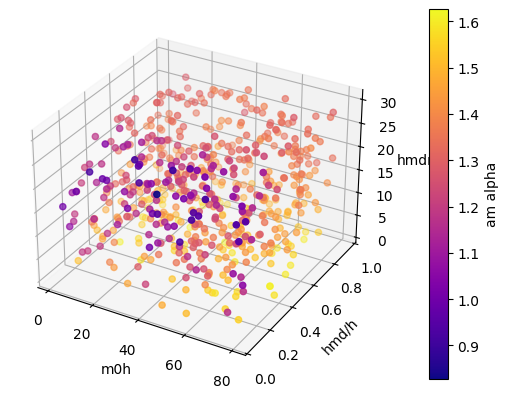

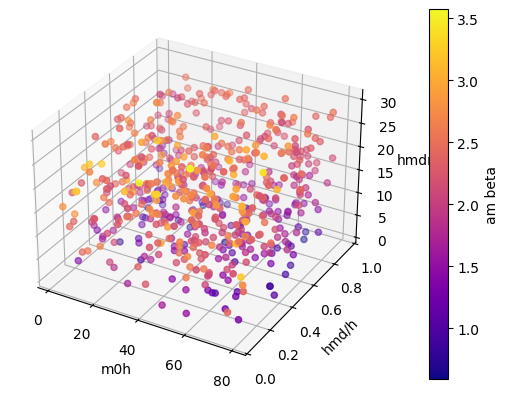

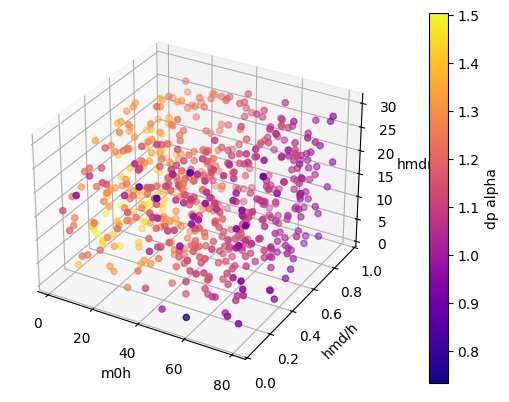

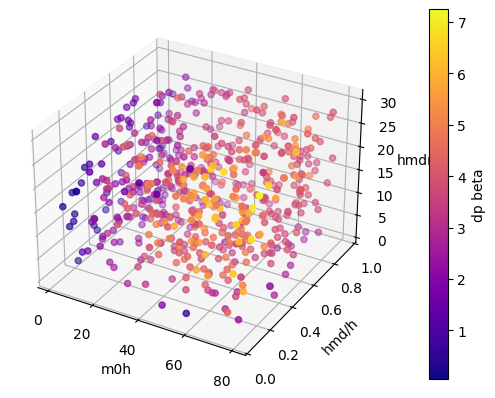

In [34]:
plot_4tuples_3d(data_am_alpha, cmap = "plasma", xlab = "m0h", ylab = "hmd/h", zlab = "hmdr", title = None, clabel = "am alpha")
plot_4tuples_3d(data_am_beta, cmap = "plasma", xlab = "m0h", ylab = "hmd/h", zlab = "hmdr", title = None, clabel = "am beta")
plot_4tuples_3d(data_dp_alpha, cmap = "plasma", xlab = "m0h", ylab = "hmd/h", zlab = "hmdr", title = None, clabel = "dp alpha")
plot_4tuples_3d(data_dp_beta, cmap = "plasma", xlab = "m0h", ylab = "hmd/h", zlab = "hmdr", title = None, clabel = "dp beta")

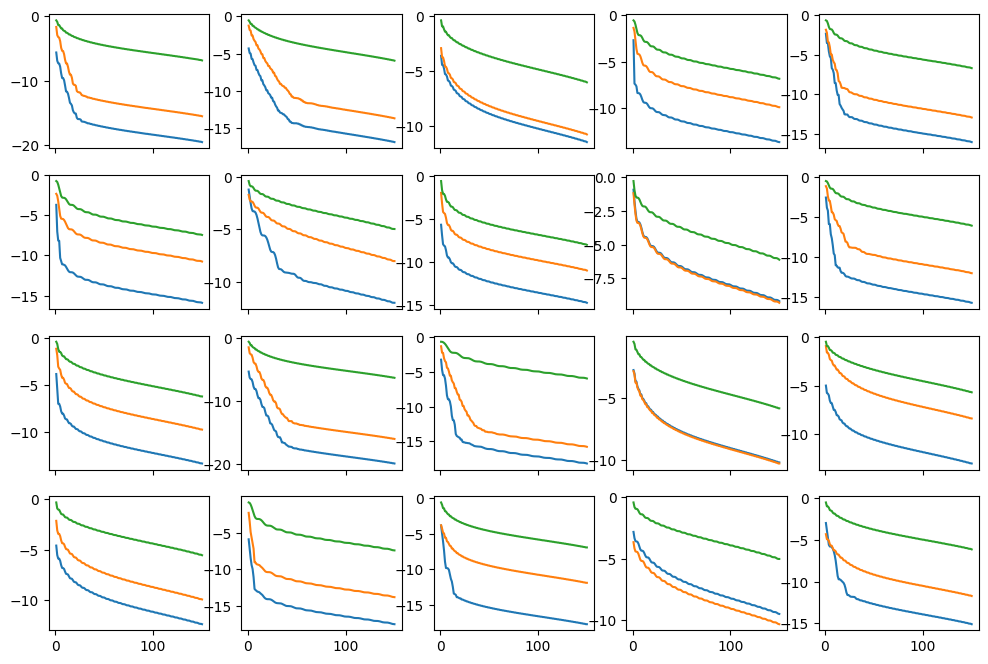

In [37]:
xs = list(range(1, 151))
fig, axs = plt.subplots(4, 5, figsize=(12, 8), sharex=True)
for row in range(4):
  for col in range(5):
    cf = ext_data[row * 5 + col]
    for i in range(3):
      ys = cf[i]["am log errs"]
      axs[row, col].plot(xs, ys)
plt.show()

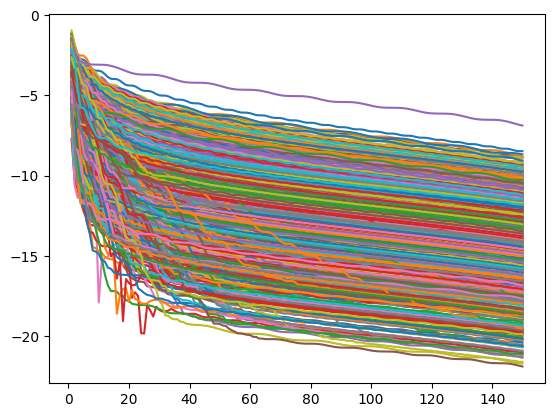

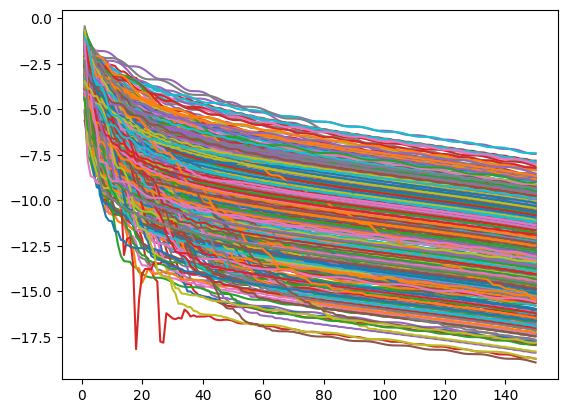

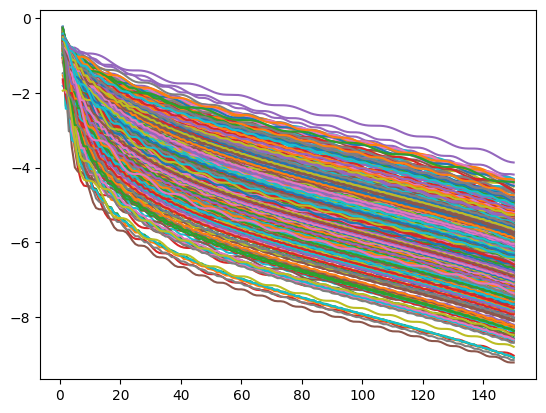

In [22]:
xs = list(range(1, 151))
for i in range(3):
  for cf in ext_data:
    ys = cf[i]["am log errs"]
    plt.plot(xs, ys)
  plt.show()